# DELCODE MCI Converter Analysis

I am only considering the patient IDs that show up in the metadata file.
I am aware of the fact that there are fMRI scans with patient IDs that do not show up in the metadata file.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path

DATA_DIR = Path('/dss/dssfs03/pn72zi/pn72zi-dss-0001/di38jor/Projects/Delcode/all_data')
PHENO_DIR = DATA_DIR / 'Antrag_462_Ruat_DysConnectivity_Index_20240320'
TIMEPOINTS = ['DELCODE_M0_combined_SWI_only', 'DELCODE_M12_combined_SWI_only', 
              'DELCODE_M24_combined_SWI_only', 'DELCODE_M36_combined_SWI_only',
              'DELCODE_M48_combined_SWI_only', 'DELCODE_M60_combined']
TP_NAMES = ['M0', 'M12', 'M24', 'M36', 'M48', 'M60']

def get_mri_subjects(tp_dir, scan_type=None):
    subjects = set()
    if tp_dir.exists():
        for f in tp_dir.iterdir():
            if scan_type is None or f'_{scan_type}_' in f.name:
                match = re.match(r'^([a-f0-9]+)-', f.name)
                if match:
                    subjects.add(match.group(1))
    return subjects

---
## 1. Load Data (working on copies)

In [2]:
baseline_raw = pd.read_excel(PHENO_DIR / 'Antrag_462_Ruat_DysConnectivity Index_20240320_DELCODE_Baseline_repseudonymisiert.xlsx', header=1)
followup_raw = pd.read_excel(PHENO_DIR / 'Antrag_462_Ruat_DysConnectivity Index_20240320DELCODE_Follow-up_repseudonymisiert.xlsx', header=1)

baseline = baseline_raw.copy()
followup = followup_raw.copy()

print(f'Baseline: {len(baseline)} subjects')
print(f'Follow-up: {len(followup)} visits, {followup["Repseudonym"].nunique()} unique subjects')

diag_map = {0:'HC', 1:'SCD', 2:'MCI', 5:'AD', 100:'Relatives'}
print(f'\nDiagnosis distribution:')
print(baseline['prmdiag'].value_counts().rename(diag_map))

Baseline: 937 subjects
Follow-up: 4077 visits, 854 unique subjects

Diagnosis distribution:
prmdiag
SCD          381
HC           221
MCI          157
AD           107
Relatives     71
Name: count, dtype: int64


In [3]:
print('Follow-up visits (visnam column):')
print('Note: "Tel" = Telephone follow-up (remote assessment when patient could not come in person)')
print(followup['visnam'].value_counts().sort_index())

Follow-up visits (visnam column):
Note: "Tel" = Telephone follow-up (remote assessment when patient could not come in person)
visnam
Follow-up 1        822
Follow-up 2        704
Follow-up 2 Tel      7
Follow-up 3        635
Follow-up 3 Tel     17
Follow-up 4        532
Follow-up 4 Tel     17
Follow-up 5        459
Follow-up 5 Tel     26
Follow-up 6        339
Follow-up 6 Tel     29
Follow-up 7        260
Follow-up 7 Tel      9
Follow-up 8        169
Follow-up 8 Tel      1
Follow-up 9         51
Name: count, dtype: int64


---
## 2. MCI Longitudinal Tracking

In [4]:
mci_ids = baseline[baseline['prmdiag'] == 2]['Repseudonym'].tolist()
mci_fu = followup[followup['Repseudonym'].isin(mci_ids)][['Repseudonym', 'visnam', 'demyn', 'visdat']].copy()
mci_fu['demyn_flag'] = mci_fu['demyn'].apply(lambda x: str(x) == '1')
mci_fu['visit_num'] = mci_fu['visnam'].str.extract(r'Follow-up (\d+)').astype(float)

print(f'MCI at baseline: {len(mci_ids)}')
print(f'MCI with follow-up data: {mci_fu["Repseudonym"].nunique()}')
print(f'MCI without follow-up: {len(mci_ids) - mci_fu["Repseudonym"].nunique()}')

MCI at baseline: 157
MCI with follow-up data: 141
MCI without follow-up: 16


In [13]:
trajectory_list = []
for subj_id in mci_ids:
    subj_data = mci_fu[mci_fu['Repseudonym'] == subj_id].sort_values('visit_num')
    row = {'Repseudonym': subj_id, 'converted': False, 'conversion_year': np.nan}
    converted = False
    for _, visit in subj_data.iterrows():
        v = int(visit['visit_num']) if pd.notna(visit['visit_num']) else None
        if v is None:
            continue
        if visit['demyn_flag'] and not converted:
            converted = True
            row['conversion_year'] = v
            row['converted'] = True
        row[f'Year{v}'] = 'Converted' if converted else 'MCI'
    trajectory_list.append(row)

mci_trajectory = pd.DataFrame(trajectory_list)

year_cols = [c for c in mci_trajectory.columns if c.startswith('Year')]
year_cols_sorted = sorted(year_cols, key=lambda x: int(x.replace('Year', '')))
other_cols = ['Repseudonym', 'converted', 'conversion_year']
mci_trajectory = mci_trajectory[other_cols + year_cols_sorted]

print(f'Converters: {mci_trajectory["converted"].sum()}')
print(f'Non-converters: {(~mci_trajectory["converted"]).sum()}')
mci_trajectory.head(20)

Converters: 59
Non-converters: 98


,Repseudonym,converted,conversion_year,Year1,Year2,Year3,Year4,Year5,Year6,Year7,Year8,Year9
0,5598d51dd,True,1.0,Converted,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,aaa7ce134,False,NaN,MCI,MCI,NaN,MCI,MCI,MCI,MCI,MCI,NaN
2,700039701,False,NaN,MCI,MCI,MCI,MCI,MCI,MCI,MCI,MCI,NaN
3,073b63746,False,NaN,MCI,MCI,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7bd198732,False,NaN,MCI,MCI,NaN,MCI,MCI,NaN,NaN,NaN,NaN
5,fd225d1ef,True,1.0,Converted,Converted,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,a5cceacea,True,4.0,NaN,MCI,NaN,Converted,Converted,NaN,NaN,NaN,NaN
7,c31b2cac2,False,NaN,MCI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,75d45f9f7,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,9b16d9da3,True,6.0,MCI,MCI,MCI,MCI,MCI,Converted,NaN,NaN,NaN


In [6]:
print('Conversion year distribution:')
print(mci_trajectory[mci_trajectory['converted']]['conversion_year'].value_counts().sort_index())

Conversion year distribution:
conversion_year
1.0    18
2.0    15
3.0     6
4.0     6
5.0     5
6.0     6
7.0     2
8.0     1
Name: count, dtype: int64


---
## 3. Filter to MCI with fMRI Scans

In [7]:
all_fmri_subjects = set()
for tp in TIMEPOINTS:
    all_fmri_subjects.update(get_mri_subjects(DATA_DIR / tp, 'T1'))

mci_with_fmri = [s for s in mci_ids if s in all_fmri_subjects]
mci_trajectory_fmri = mci_trajectory[mci_trajectory['Repseudonym'].isin(mci_with_fmri)].copy()

print(f'Total MCI: {len(mci_ids)}')
print(f'MCI with fMRI: {len(mci_with_fmri)}')
print(f'Converters with fMRI: {mci_trajectory_fmri["converted"].sum()}')
print(f'Non-converters with fMRI: {(~mci_trajectory_fmri["converted"]).sum()}')
print(f'\nconversion_year column shows NaN for non-converters:')
mci_trajectory_fmri

Total MCI: 157
MCI with fMRI: 157
Converters with fMRI: 59
Non-converters with fMRI: 98

conversion_year column shows NaN for non-converters:


,Repseudonym,converted,conversion_year,Year1,Year2,Year3,Year4,Year5,Year6,Year7,Year8,Year9
0,5598d51dd,True,1.0,Converted,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,aaa7ce134,False,NaN,MCI,MCI,NaN,MCI,MCI,MCI,MCI,MCI,NaN
2,700039701,False,NaN,MCI,MCI,MCI,MCI,MCI,MCI,MCI,MCI,NaN
3,073b63746,False,NaN,MCI,MCI,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7bd198732,False,NaN,MCI,MCI,NaN,MCI,MCI,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
152,1169cb29f,True,4.0,MCI,MCI,NaN,Converted,NaN,Converted,NaN,NaN,NaN
153,4e73cdc52,True,2.0,MCI,Converted,NaN,NaN,NaN,NaN,NaN,NaN,NaN
154,836c233ff,True,3.0,MCI,MCI,Converted,Converted,NaN,Converted,Converted,NaN,NaN
155,e25c67e62,False,NaN,MCI,MCI,MCI,NaN,MCI,MCI,NaN,NaN,NaN


---
## 4. Trajectory Plot

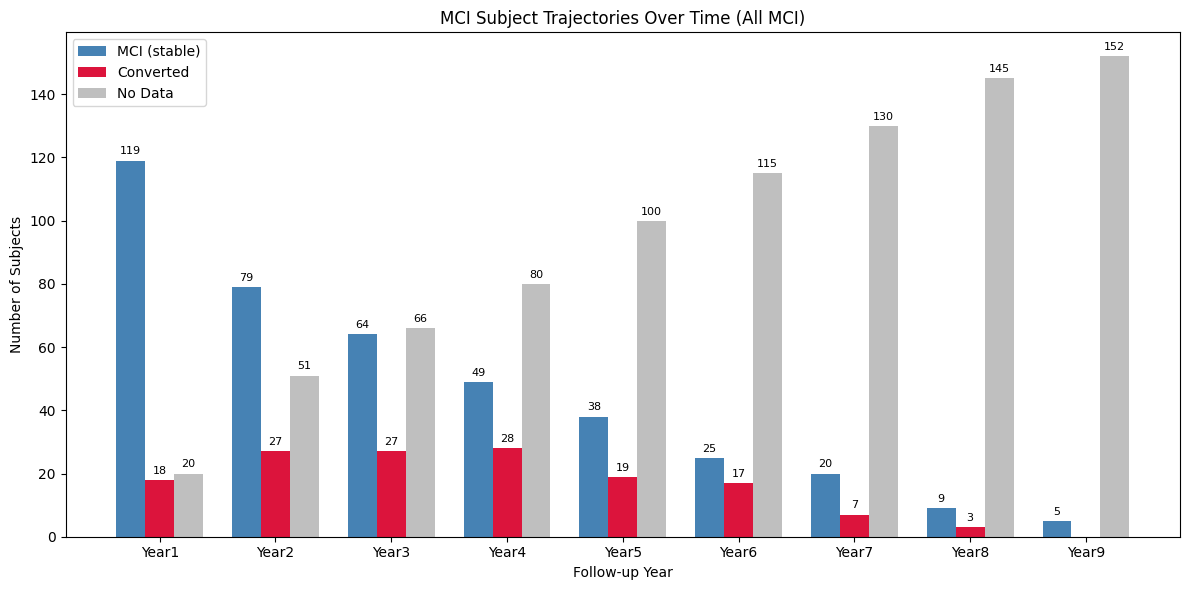

In [ ]:
status_counts = pd.DataFrame(index=['MCI', 'Converted', 'No Data'])
for col in year_cols_sorted:
    counts = mci_trajectory[col].value_counts(dropna=False)
    no_data = len(mci_trajectory) - mci_trajectory[col].notna().sum()
    status_counts[col] = [counts.get('MCI', 0), counts.get('Converted', 0), no_data]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(year_cols_sorted))
width = 0.25

bars_mci = ax.bar(x - width, status_counts.loc['MCI'], width, label='MCI (stable)', color='steelblue')
bars_conv = ax.bar(x, status_counts.loc['Converted'], width, label='Converted', color='crimson')
bars_nodata = ax.bar(x + width, status_counts.loc['No Data'], width, label='No Data', color='gray', alpha=0.5)

for bar in bars_mci:
    height = bar.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)

for bar in bars_conv:
    height = bar.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)

for bar in bars_nodata:
    height = bar.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Follow-up Year')
ax.set_ylabel('Number of Subjects')
ax.set_title('MCI Subject Trajectories Over Time')
ax.set_xticks(x)
ax.set_xticklabels(year_cols_sorted)
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. fMRI Availability per Timepoint

In [9]:
converters = mci_trajectory[mci_trajectory['converted']]['Repseudonym'].tolist()
nonconverters = mci_trajectory[~mci_trajectory['converted']]['Repseudonym'].tolist()

fmri_results = []
for tp, tp_name in zip(TIMEPOINTS, TP_NAMES):
    fmri_subj = get_mri_subjects(DATA_DIR / tp, 'T1')
    conv_fmri = set(converters) & fmri_subj
    nonconv_fmri = set(nonconverters) & fmri_subj
    fmri_results.append({
        'Timepoint': tp_name,
        'Converters': len(conv_fmri),
        'NonConverters': len(nonconv_fmri),
        'Total': len(conv_fmri) + len(nonconv_fmri)
    })

fmri_df = pd.DataFrame(fmri_results)
print('fMRI (T1) availability for MCI subjects:')
print(fmri_df.to_string(index=False))

fMRI (T1) availability for MCI subjects:
Timepoint  Converters  NonConverters  Total
       M0          57             97    154
      M12          54             70    124
      M24          40             39     79
      M36          28             34     62
      M48          19             28     47
      M60          15             17     32


---
## 5 Progressive Buildup of fMRI Scans

This plot shows the accumulation of usable fMRI scans:
- **Non-converters**: All available fMRI scans
- **Converters**: Only fMRI scans taken BEFORE conversion (excluding conversion timepoint and after)

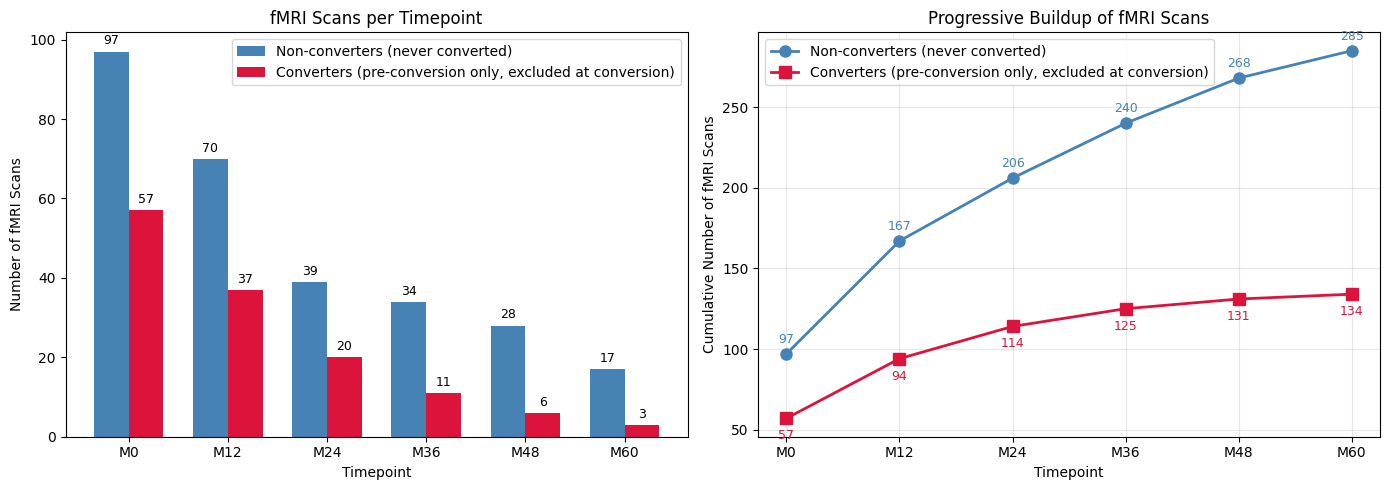


=== Progressive Buildup Summary ===
Non-converters: 285 total scans from 98 subjects
Converters (pre-conversion): 134 total scans from 59 subjects


In [16]:
# Progressive Buildup Plot: fMRI scans over time
# Non-converters: all available scans
# Converters: only scans BEFORE conversion (not at or after)

# Map timepoints to "years" (M0=0, M12=1, M24=2, etc.)
tp_to_year = {'M0': 0, 'M12': 1, 'M24': 2, 'M36': 3, 'M48': 4, 'M60': 5}

# Get converter info (subject -> conversion_year)
converter_info = mci_trajectory[mci_trajectory['converted']][['Repseudonym', 'conversion_year']].set_index('Repseudonym')['conversion_year'].to_dict()
converter_ids = set(converter_info.keys())
nonconverter_ids = set(mci_trajectory[~mci_trajectory['converted']]['Repseudonym'].tolist())

# Count scans at each timepoint
nonconv_counts = []  # Non-converters: all scans
conv_counts = []     # Converters: only before conversion

for tp, tp_name in zip(TIMEPOINTS, TP_NAMES):
    tp_year = tp_to_year[tp_name]
    fmri_subj = get_mri_subjects(DATA_DIR / tp, 'T1')
    
    # Non-converters: count all who have fMRI at this timepoint
    nonconv_with_scan = len(fmri_subj & nonconverter_ids)
    nonconv_counts.append(nonconv_with_scan)
    
    # Converters: count only those whose conversion_year > tp_year
    conv_with_scan = 0
    for subj_id in (fmri_subj & converter_ids):
        conv_year = converter_info[subj_id]
        # Only count if conversion happens AFTER this timepoint
        if tp_year < conv_year:
            conv_with_scan += 1
    conv_counts.append(conv_with_scan)

# Cumulative buildup
nonconv_cumulative = np.cumsum(nonconv_counts)
conv_cumulative = np.cumsum(conv_counts)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot showing scans per timepoint
x = np.arange(len(TP_NAMES))
width = 0.35

bars1 = ax1.bar(x - width/2, nonconv_counts, width, label='Non-converters (never converted)', color='steelblue')
bars2 = ax1.bar(x + width/2, conv_counts, width, label='Converters (pre-conversion only, excluded at conversion)', color='crimson')

for bar in bars1:
    height = bar.get_height()
    if height > 0:
        ax1.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    if height > 0:
        ax1.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=9)

ax1.set_xlabel('Timepoint')
ax1.set_ylabel('Number of fMRI Scans')
ax1.set_title('fMRI Scans per Timepoint')
ax1.set_xticks(x)
ax1.set_xticklabels(TP_NAMES)
ax1.legend()

# Cumulative buildup plot
ax2.plot(TP_NAMES, nonconv_cumulative, 'o-', label='Non-converters (never converted)', color='steelblue', linewidth=2, markersize=8)
ax2.plot(TP_NAMES, conv_cumulative, 's-', label='Converters (pre-conversion only, excluded at conversion)', color='crimson', linewidth=2, markersize=8)

for i, (nc, c) in enumerate(zip(nonconv_cumulative, conv_cumulative)):
    ax2.annotate(f'{nc}', xy=(i, nc), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=9, color='steelblue')
    ax2.annotate(f'{c}', xy=(i, c), xytext=(0, -15), textcoords='offset points', ha='center', fontsize=9, color='crimson')

ax2.set_xlabel('Timepoint')
ax2.set_ylabel('Cumulative Number of fMRI Scans')
ax2.set_title('Progressive Buildup of fMRI Scans')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print(f"\n=== Progressive Buildup Summary ===")
print(f"Non-converters: {nonconv_cumulative[-1]} total scans from {len(nonconverter_ids)} subjects")
print(f"Converters (pre-conversion): {conv_cumulative[-1]} total scans from {len(converter_ids)} subjects")

---
## 6. Data Integrity Check

---
## 7. Compare with Colleague's Converter Data

Compare our converter list with the colleague's postprocessed converters at:
`/dss/dssfs03/pn72zi/pn72zi-dss-0001/di38jor/Projects/Delcode/data/Converter_newcriteria/postprocessed`

In [17]:
# Compare with colleague's converter data
import os

COLLEAGUE_DIR = Path('/dss/dssfs03/pn72zi/pn72zi-dss-0001/di38jor/Projects/Delcode/data/Converter_newcriteria/postprocessed')

# Colleague's timepoints mapping
colleague_tp_map = {
    'M0': 'Postprocessed_M0',
    'M12': 'Postprocessed_M12',
    'M24': 'Postprocessed_M24',
    'M36': 'Postprocessed_M36',
    'M48': 'Postprocessed_M48',
    'M60': 'Postprocessed_M60'
}

def get_colleague_subjects(tp_dir):
    """Extract subject IDs from colleague's postprocessed directory."""
    subjects = set()
    if tp_dir.exists():
        for d in tp_dir.iterdir():
            if d.is_dir() and d.name.startswith('sub-'):
                # Extract ID after 'sub-'
                subjects.add(d.name[4:])
    return subjects

# Compare for each timepoint
print('=== Comparison: My Converters vs Colleague\'s Converters ===\n')

for tp_name in TP_NAMES:
    # My converters with fMRI at this timepoint
    my_fmri = get_mri_subjects(DATA_DIR / TIMEPOINTS[TP_NAMES.index(tp_name)], 'T1')
    my_converters_fmri = my_fmri & set(converters)
    
    # Colleague's converters at this timepoint
    colleague_tp_dir = COLLEAGUE_DIR / colleague_tp_map[tp_name]
    colleague_converters = get_colleague_subjects(colleague_tp_dir)
    
    # Differences
    only_mine = my_converters_fmri - colleague_converters
    only_colleague = colleague_converters - my_converters_fmri
    common = my_converters_fmri & colleague_converters
    
    print(f'--- {tp_name} ---')
    print(f'My converters with fMRI: {len(my_converters_fmri)}')
    print(f'Colleague\'s converters: {len(colleague_converters)}')
    print(f'Common: {len(common)}')
    
    if only_mine:
        print(f'Only in my list ({len(only_mine)}): {sorted(list(only_mine))}')
    if only_colleague:
        print(f'Only in colleague\'s list ({len(only_colleague)}): {sorted(list(only_colleague))}')
    print()

=== Comparison: My Converters vs Colleague's Converters ===

--- M0 ---
My converters with fMRI: 57
Colleague's converters: 69
Common: 57
Only in colleague's list (12): ['07e48dffa', '40feb97f6', '4359a0c41', '5759da909', '7bc92ad6d', 'b2cc7cce8', 'b2f42b7ff', 'be658a955', 'c13fa705c', 'd7f5479f6', 'fd0a4ba8a', 'fff6c90a3']

--- M12 ---
My converters with fMRI: 54
Colleague's converters: 61
Common: 50
Only in my list (4): ['0588be6c5', '434050aec', 'd4055734e', 'da07ac132']
Only in colleague's list (11): ['07e48dffa', '40feb97f6', '4359a0c41', '5759da909', '7bc92ad6d', 'b2f42b7ff', 'be658a955', 'c13fa705c', 'd7f5479f6', 'dca63a3ab', 'fff6c90a3']

--- M24 ---
My converters with fMRI: 40
Colleague's converters: 40
Common: 32
Only in my list (8): ['03a0a6663', '1169cb29f', '434050aec', '75d14b5ca', 'a5cceacea', 'bcae977b3', 'd4055734e', 'fdb1d843b']
Only in colleague's list (8): ['07e48dffa', '4359a0c41', 'b2cc7cce8', 'be658a955', 'd7f5479f6', 'dca63a3ab', 'fd0a4ba8a', 'fff6c90a3']

--- M

---
## 6. Data Integrity Check

In [10]:
all_mri_subjects = set()
for tp in TIMEPOINTS:
    all_mri_subjects.update(get_mri_subjects(DATA_DIR / tp))

all_excel_ids = set(baseline['Repseudonym'].tolist())
excel_only = all_excel_ids - all_mri_subjects
mri_only = all_mri_subjects - all_excel_ids

print('=== Data Integrity ===')
print(f'Excel subjects: {len(all_excel_ids)}')
print(f'MRI subjects: {len(all_mri_subjects)}')
print(f'Matched: {len(all_excel_ids & all_mri_subjects)}')
print(f'Excel-only (no MRI): {len(excel_only)}')
print(f'MRI-only (not in Excel): {len(mri_only)}')

if mri_only:
    print(f'\nMRI-only IDs: {sorted(list(mri_only))}')

=== Data Integrity ===
Excel subjects: 937
MRI subjects: 976
Matched: 937
Excel-only (no MRI): 0
MRI-only (not in Excel): 39

MRI-only IDs: ['0165e2425', '0334c87f0', '03a9c76de', '0c1c5ae77', '0c8ca3f3b', '1ee398dc5', '2075afe4c', '2395cf9e2', '28cf0df4c', '2ac3bd892', '40c6ddbad', '43db1dacb', '440b5327f', '482c864dd', '491a6bfc9', '4d1fc697e', '4db84ad1e', '57e9fafc7', '58a070b73', '59b3ac83c', '5d0276e4b', '6c8fd9b20', '858860a88', '87e453af1', '9197b4d1d', 'bc789238a', 'bd3a00015', 'be8ce5d42', 'c35ddeb62', 'c9d453efd', 'd13d9cba4', 'd1cea034b', 'd621c4094', 'd7849c9fe', 'e3cf25b67', 'e8d68a81a', 'e9750a39a', 'ec54e9b23', 'fe51a07c7']
